In [1]:
# import thư viện cần thiết
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

# chia dataset, chọn model, scaling feature, lưu metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    RandomTreesEmbedding,
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
) 
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# lưu model để tái sử dụng
import joblib

print("import thành công")

import thành công


In [2]:
# import dataset
# os.listdir("/kaggle/input/datasets/letatdinh/melb-data-house-pricing")

df = pd.read_csv("/kaggle/input/datasets/letatdinh/melb-data-house-pricing/melb_data.csv")
# print(df)
print("import dataset thành công")
print("số dòng: ", len(df))

import dataset thành công
số dòng:  13580


In [3]:
# phân tích dataset

df.describe() # thống kê mô tả

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


<Axes: >

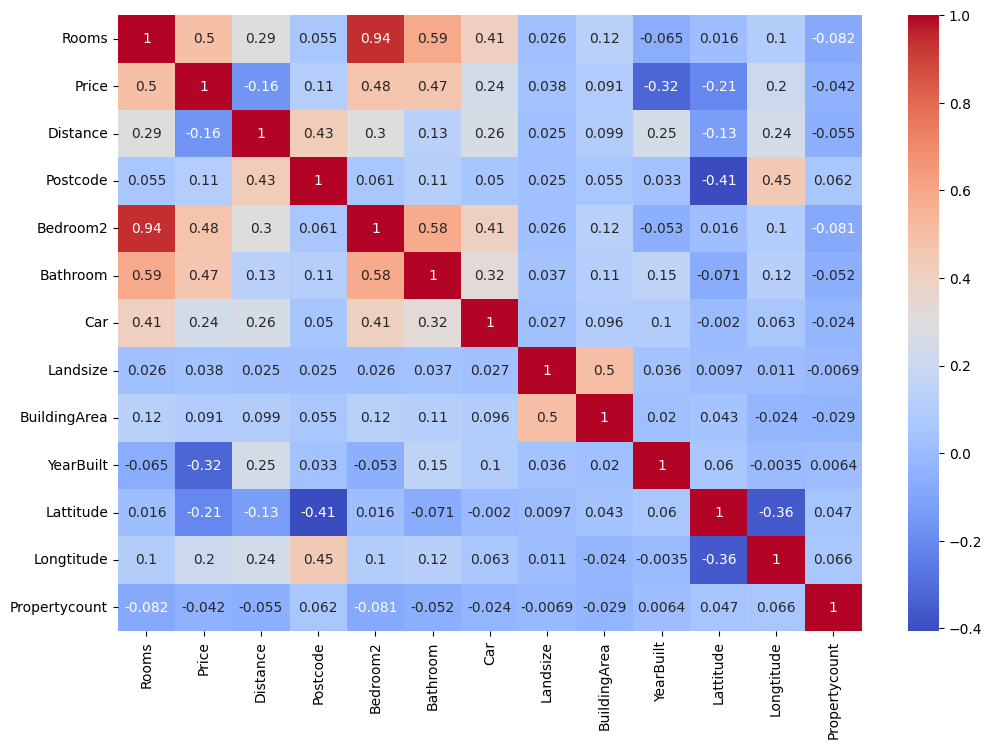

In [4]:
# tìm ra feature có ảnh hưởng mạnh
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='YearBuilt', ylabel='Price'>

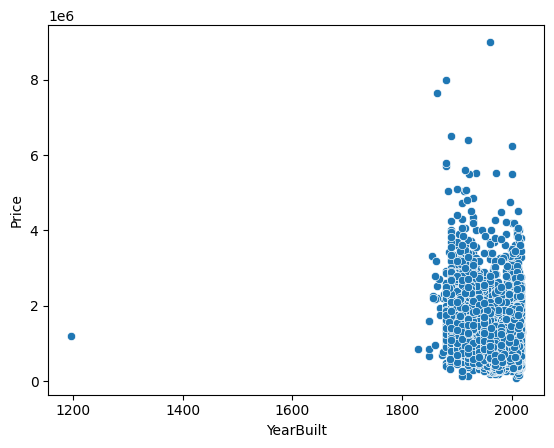

In [5]:
# phân tích (nếu x tăng thì y tăng ?)
sns.scatterplot(x='YearBuilt', y='Price', data=df)

In [6]:
# kiểm tra missing values
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [7]:
# xử lý cột Car
df['Car'] = df['Car'].fillna(df['Car'].median())


# xử lý cột Building Area
df['BuildingArea'] = df['BuildingArea'].fillna(
    df['BuildingArea'].median()
)

# xử lý cột YearBuilt
df['YearBuilt'] = df['YearBuilt'].fillna(
    df['YearBuilt'].median()
)

# xử lý cột CouncilArea
df['CouncilArea'] = df['CouncilArea'].fillna('Unknown')


In [8]:
# tái kiểm tra missing values
df.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [9]:
# encode data và tách X / Y
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Price', axis=1)

y = df['Price']


In [10]:
# chia dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
print("split dataset thành công!")

split dataset thành công!


In [11]:
# feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
print("scale thành công!")

scale thành công!


In [12]:
# train model
model = RandomForestRegressor() # tạo model cần train

model.fit(X_train, y_train) # training model

print("training thành công!")

training thành công!


In [13]:
# lưu model để tái sử dụng
# joblib.dump(model, "house_price_model.pkl")

In [14]:
# predict values

y_pred = model.predict(X_test)
print(y_pred[:5])

[2206700.   666902.5  802410.   541165.   907370. ]


In [15]:
# So sánh giữa dự đoán và giá nhà thật
comparison = pd.DataFrame({
    'Actual': y_test.astype(int),
    'Predicted': y_pred.astype(int)
})

comparison.head(15)

,Actual,Predicted
1061,2600000,2206700
6482,620000,666902
8395,1000000,802410
4659,430000,541165
7386,392250,907370
6607,700000,855830
8094,439000,501056
4590,2236000,1506365
13475,671000,614435
10318,1870000,1550880


In [16]:
# Evaluation model

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 168744.9286867943
RMSE: 303762.4831595224
R2 Score: 0.7803012467428627


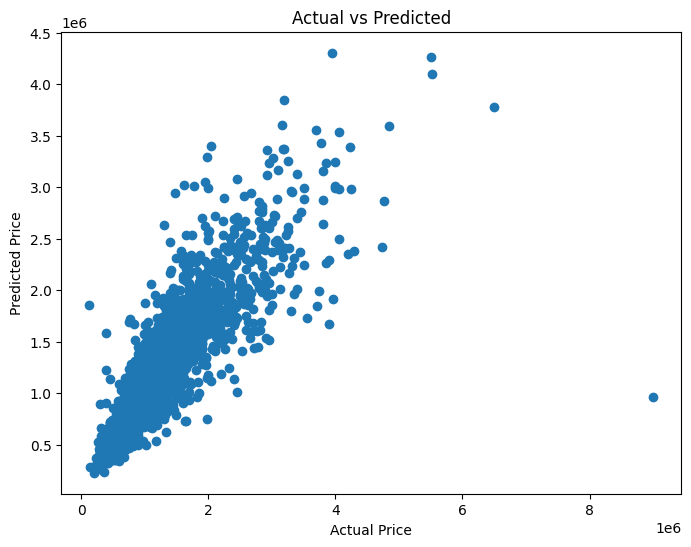

In [17]:
# trực quan dữ liệu

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()